In [2]:
import pandas as pd


In [3]:
df = pd.read_csv("../data/raw/raw_ami_tracking.csv")

In [4]:
df.head()



,patient_id,injury,date_ami,level,score_pct,tsk_11
0,P0001,ACL,1/19/2023,1,90,28.0
1,P0001,ACL,2/20/2023,2,84,29.0
2,P0001,ACL,3/16/2023,2,87,28.0
3,P0001,ACL,4/17/2023,2,92,25.0
4,P0001,ACL,5/15/2023,complete,80,24.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 415 entries, 0 to 414
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   patient_id  415 non-null    str    
 1   injury      415 non-null    str    
 2   date_ami    415 non-null    str    
 3   level       415 non-null    str    
 4   score_pct   415 non-null    str    
 5   tsk_11      181 non-null    float64
dtypes: float64(1), str(5)
memory usage: 19.6 KB


In [6]:
df.shape

(415, 6)

In [7]:
df["date_ami"] = pd.to_datetime(df["date_ami"], format="mixed", errors="coerce")
df[df["date_ami"].isna()]

,patient_id,injury,date_ami,level,score_pct,tsk_11


In [8]:
df["date_ami"].dtype
df["date_ami"].head(10)


0   2023-01-19
1   2023-02-20
2   2023-03-16
3   2023-04-17
4   2023-05-15
5   2023-06-15
6   2023-07-20
7   2023-08-15
8   2023-09-14
9   2022-10-26
Name: date_ami, dtype: datetime64[us]

In [9]:
df["score_pct"] = pd.to_numeric(
    df["score_pct"],
    errors="coerce"
)

df["tsk_11"] = pd.to_numeric(
    df["tsk_11"],
    errors="coerce"
)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 415 entries, 0 to 414
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   patient_id  415 non-null    str           
 1   injury      415 non-null    str           
 2   date_ami    415 non-null    datetime64[us]
 3   level       415 non-null    str           
 4   score_pct   414 non-null    float64       
 5   tsk_11      181 non-null    float64       
dtypes: datetime64[us](1), float64(2), str(3)
memory usage: 19.6 KB


In [11]:
df.isna().sum()

patient_id      0
injury          0
date_ami        0
level           0
score_pct       1
tsk_11        234
dtype: int64

## Data Quality Assessment

The dataset contains one missing AMI score and 234 missing TSK-11 scores.
Missing values were retained as NaN for transparency.

In [12]:
analysis_df = df.dropna(
    subset=["score_pct", "tsk_11"]
)

In [13]:
analysis_df.shape

(180, 6)

In [14]:
analysis_df.describe()

,date_ami,score_pct,tsk_11
count,180,180.000000,180.000000
mean,2023-12-08 02:56:00,75.177778,19.605556
min,2022-10-05 00:00:00,35.000000,11.000000
25%,2023-08-10 00:00:00,69.000000,14.000000
50%,2024-01-08 00:00:00,75.000000,19.000000
75%,2024-04-19 00:00:00,82.000000,25.000000
max,2025-07-30 00:00:00,98.000000,42.000000
std,NaN,10.181128,6.577851


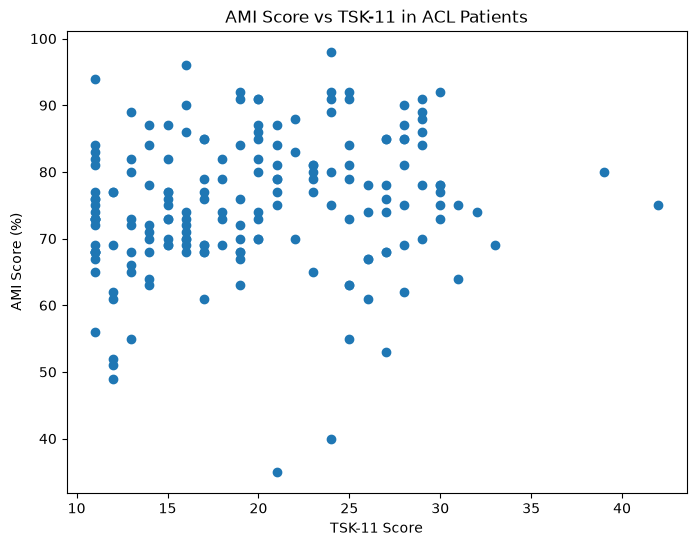

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    analysis_df["tsk_11"],
    analysis_df["score_pct"]
)

plt.xlabel("TSK-11 Score")
plt.ylabel("AMI Score (%)")
plt.title("AMI Score vs TSK-11 in ACL Patients")

plt.show()

In [16]:
analysis_df[["score_pct","tsk_11"]].corr()

,score_pct,tsk_11
score_pct,1.000000,0.190081
tsk_11,0.190081,1.000000


In [17]:
df.head()

,patient_id,injury,date_ami,level,score_pct,tsk_11
0,P0001,ACL,2023-01-19,1,90.0,28.0
1,P0001,ACL,2023-02-20,2,84.0,29.0
2,P0001,ACL,2023-03-16,2,87.0,28.0
3,P0001,ACL,2023-04-17,2,92.0,25.0
4,P0001,ACL,2023-05-15,complete,80.0,24.0


In [18]:
import os

os.makedirs("../data/processed", exist_ok=True)

In [19]:
df.to_csv(
    "../data/processed/acl_analysis.csv",
    index=False
)

In [20]:
import os

print(os.listdir("../data/processed"))

['acl_analysis.csv']
